In [1]:
# Cell 1: Environment and Architecture Definitions
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Backtest Environment Ready | Using Device: {device}")

# Base LSTM (Named layers match the training state_dict)
class StockPredictorLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=256, num_layers=1):
        super(StockPredictorLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        return self.fc2(self.relu(self.fc1(out)))

# BiLSTM Attention (Named layers match the training state_dict)
class StockPredictorBiLSTMAttention(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=2):
        super(StockPredictorBiLSTMAttention, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=0.2)
        self.attention = nn.Linear(hidden_size * 2, 1)
        self.fc1 = nn.Linear(hidden_size * 2, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context_vector = torch.sum(attn_weights * lstm_out, dim=1)
        out = self.fc1(context_vector)
        return self.fc2(self.relu(out))

# BiLSTM No-Attention (Named layers match the training state_dict)
class StockPredictorBiLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=2):
        super(StockPredictorBiLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size * 2, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc1(lstm_out[:, -1, :])
        return self.fc2(self.relu(out))


Backtest Environment Ready | Using Device: cuda


In [2]:
# Cell 2: Model Selector (Based On Median)
def get_median_run(results_folder, ticker, seq_len, prefix):
    csv_path = os.path.join(results_folder, f"{prefix}_stability_results_{seq_len}.csv")
    df = pd.read_csv(csv_path)

    ticker_df = df[df['Ticker'] == ticker].copy()
    median_val = ticker_df['R2'].median()
    ticker_df['Dist'] = (ticker_df['R2'] - median_val).abs()
    median_run_id = int(ticker_df.sort_values('Dist').iloc[0]['Run'])
    
    return median_run_id, median_val

def load_representative_model(model_path, model_type, params):
    if model_type == 'v1':
        model = StockPredictorLSTM(**params)
    elif model_type == 'v2_attention':
        model = StockPredictorBiLSTMAttention(**params)
    elif model_type == 'v2_no_attention':
        model = StockPredictorBiLSTM(**params)
    
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    return model.to(device).eval()


In [3]:
# Cell 3: Prepare Backtest Data
def prepare_backtest_data(ticker, seq_len):
    df = pd.read_csv(f"datasets/{ticker}/{ticker}_DatasetV1.csv")
    df['Trading_Date'] = pd.to_datetime(df['Trading_Date'])
    
    train_raw = df[df['Trading_Date'].dt.year <= 2022].copy()
    test_raw = df[df['Trading_Date'].dt.year == 2023].copy()
    
    scaler = MinMaxScaler()
    cols = ['Close', 'Volume', 'Sentiment', 'SMA_20', 'RSI_14']
    scaler.fit(train_raw[cols]) # Fit on training to set the scale
    
    test_scaled = scaler.transform(test_raw[cols])
    
    X, y_actual, prev_close = [], [], []
    dates = []
    
    for i in range(len(test_scaled) - seq_len):
        X.append(test_scaled[i : i + seq_len])
        y_actual.append(test_raw['Close'].iloc[i + seq_len])
        prev_close.append(test_raw['Close'].iloc[i + seq_len - 1])
        dates.append(test_raw['Trading_Date'].iloc[i + seq_len])
        
    return torch.tensor(np.array(X), dtype=torch.float32).to(device), np.array(y_actual), np.array(prev_close), dates, scaler


In [4]:
# Cell 4: Market Sim (Optimized for 4 and 5 features)
def run_simulation(model, X_test, actual_prices, prev_prices, dates, scaler, cost=0.001):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test).cpu().numpy().flatten()
    
    # --- DYNAMIC INVERSE SCALING ---
    # Automatically detects if the scaler expects 4 features (Price-Only) or 5 (Multimodal)
    n_feats = scaler.n_features_in_
    dummy = np.zeros((len(preds_scaled), n_feats))
    dummy[:, 0] = preds_scaled 
    preds_unscaled = scaler.inverse_transform(dummy)[:, 0]
    
    results = pd.DataFrame({
        'Date': dates, 
        'Actual_Today': actual_prices, 
        'Actual_Yesterday': prev_prices, 
        'Pred_Today': preds_unscaled
    })
    
    # ROI & Signal Calculation
    results['Market_Return'] = (results['Actual_Today'] - results['Actual_Yesterday']) / results['Actual_Yesterday']
    results['Signal'] = (results['Pred_Today'] > results['Actual_Yesterday']).astype(int)
    results['Turnover'] = results['Signal'].diff().abs().fillna(0)
    results['Strategy_Return'] = (results['Signal'] * results['Market_Return']) - (results['Turnover'] * cost)
    
    # Financial Performance
    cum_strategy = (1 + results['Strategy_Return']).cumprod()
    cum_market = (1 + results['Market_Return']).cumprod()
    
    return {
        'Total_ROI (%)': (cum_strategy.iloc[-1] - 1) * 100 if not cum_strategy.empty else 0,
        'Sharpe': np.sqrt(252) * results['Strategy_Return'].mean() / (results['Strategy_Return'].std() + 1e-9),
        'BuyHold_ROI (%)': (cum_market.iloc[-1] - 1) * 100 if not cum_market.empty else 0
    }


In [7]:
# Cell 5: Master Execution Loop
import os

# --- CONFIGURE ALL 4 MODELS ---
CONFIGS = [
    {'name': 'V1 Price-Only', 'folder': 'results/trainV1_PriceOnly',   'prefix': 'v1PriceOnly', 'arch': 'v1_PriceOnly', 'input_size': 4},
    {'name': 'V1 Baseline',   'folder': 'results/trainV1',             'prefix': 'v1',          'arch': 'v1',            'input_size': 5},
    {'name': 'V2 Attention',  'folder': 'results/trainV2_attention',   'prefix': 'v2_att',      'arch': 'v2_attention',  'input_size': 5},
    {'name': 'V2 No-Attention','folder': 'results/trainV2_no_attention','prefix': 'v2_no_att','arch': 'v2_no_attention','input_size': 5}
]

# Set up results directory
SAVE_DIR = "results/backtest_summary"
os.makedirs(SAVE_DIR, exist_ok=True)

master_results = []

for ticker in ['MSFT', 'DIS', 'WMT']:
    for seq in [5, 10, 20]:
        print(f"\nProcessing: {ticker} (Seq: {seq})")
        
        for cfg in CONFIGS:
            try:
                # 1. Prepare data specifically for this model's feature set
                df = pd.read_csv(f"datasets/{ticker}/{ticker}_DatasetV1.csv")
                df['Trading_Date'] = pd.to_datetime(df['Trading_Date'])
                train_raw = df[df['Trading_Date'].dt.year <= 2022].copy()
                test_raw = df[df['Trading_Date'].dt.year == 2023].copy()
                
                # Use 4 columns for V0, 5 columns for everything else
                cols = ['Close', 'Volume', 'SMA_20', 'RSI_14'] if cfg['input_size'] == 4 else ['Close', 'Volume', 'Sentiment', 'SMA_20', 'RSI_14']
                
                scaler = MinMaxScaler()
                scaler.fit(train_raw[cols])
                
                # Transform data and create sequences
                test_scaled = scaler.transform(test_raw[cols])
                X_list, y_actual, prev_prices, dates = [], [], [], []
                for i in range(len(test_scaled) - seq):
                    X_list.append(test_scaled[i : i + seq])
                    y_actual.append(test_raw['Close'].iloc[i+seq])
                    prev_prices.append(test_raw['Close'].iloc[i+seq-1])
                    dates.append(test_raw['Trading_Date'].iloc[i+seq])
                X_test_t = torch.tensor(np.array(X_list), dtype=torch.float32).to(device)

                # 2. Load the median run
                run, r2 = get_median_run(cfg['folder'], ticker, seq, cfg['prefix'])
                m_path = f"models/{cfg['arch']}/{ticker}/{cfg['prefix']}_run_{run}_seq{seq}.pth"
                
                # Select correct class (V1 class handles both V0 and V1)
                m_type = 'v1' if 'v1' in cfg['arch'] else cfg['arch']
                model = load_representative_model(m_path, m_type, 
                                                 {'input_size': cfg['input_size'], 
                                                  'hidden_size': 256 if 'v1' in cfg['arch'] else 128})
                
                # 3. Predict & Simulate
                sim = run_simulation(model, X_test_t, y_actual, prev_prices, dates, scaler)
                
                master_results.append({
                    'Ticker': ticker, 'Seq': seq, 'Model': cfg['name'],
                    'Med_R2': r2, 'ROI_%': sim['Total_ROI (%)'], 'Sharpe': sim['Sharpe'], 'B&H_%': sim['BuyHold_ROI (%)']
                })
                print(f"  - {cfg['name']}: ROI {sim['Total_ROI (%)']:.2f}%")
                
            except Exception as e:
                print(f"  x Error in {cfg['name']}: {e}")

# 4. Save Final Report
final_df = pd.DataFrame(master_results)
final_df.to_csv(f"{SAVE_DIR}/Master_Financial_Comparison.csv", index=False)
print(f"\n[DONE] Final report saved to: {SAVE_DIR}/Master_Financial_Comparison.csv")
display(final_df)



Processing: MSFT (Seq: 5)
  - V1 Price-Only: ROI 35.01%
  - V1 Baseline: ROI 24.85%
  - V2 Attention: ROI 24.49%
  - V2 No-Attention: ROI 6.89%

Processing: MSFT (Seq: 10)
  - V1 Price-Only: ROI 59.05%
  - V1 Baseline: ROI 22.10%
  - V2 Attention: ROI 30.17%
  - V2 No-Attention: ROI 18.81%

Processing: MSFT (Seq: 20)
  - V1 Price-Only: ROI 10.97%
  - V1 Baseline: ROI 15.31%
  - V2 Attention: ROI 59.20%
  - V2 No-Attention: ROI 17.61%

Processing: DIS (Seq: 5)
  - V1 Price-Only: ROI -9.59%
  - V1 Baseline: ROI -24.27%
  - V2 Attention: ROI -8.60%
  - V2 No-Attention: ROI -7.56%

Processing: DIS (Seq: 10)
  - V1 Price-Only: ROI -7.99%
  - V1 Baseline: ROI -12.86%
  - V2 Attention: ROI 0.77%
  - V2 No-Attention: ROI -19.68%

Processing: DIS (Seq: 20)
  - V1 Price-Only: ROI -22.65%
  - V1 Baseline: ROI -30.18%
  - V2 Attention: ROI 6.15%
  - V2 No-Attention: ROI -16.92%

Processing: WMT (Seq: 5)
  - V1 Price-Only: ROI -6.57%
  - V1 Baseline: ROI 2.44%
  - V2 Attention: ROI 0.43%
  - V2 No

,Ticker,Seq,Model,Med_R2,ROI_%,Sharpe,B&H_%
0,MSFT,5,V1 Price-Only,0.979590,35.014249,1.879926,65.926469
1,MSFT,5,V1 Baseline,0.972365,24.854502,1.793104,65.926469
2,MSFT,5,V2 Attention,0.970335,24.486581,1.781670,65.926469
3,MSFT,5,V2 No-Attention,0.966451,6.889068,1.438563,65.926469
4,MSFT,10,V1 Price-Only,0.965354,59.049896,2.323729,56.793101
5,MSFT,10,V1 Baseline,0.961810,22.096809,1.701235,56.793101
6,MSFT,10,V2 Attention,0.970581,30.165176,2.147992,56.793101
7,MSFT,10,V2 No-Attention,0.975953,18.807551,1.502331,56.793101
8,MSFT,20,V1 Price-Only,0.942286,10.966157,1.147930,52.073038
9,MSFT,20,V1 Baseline,0.968040,15.306049,1.242297,52.073038


<Figure size 1500x600 with 0 Axes>

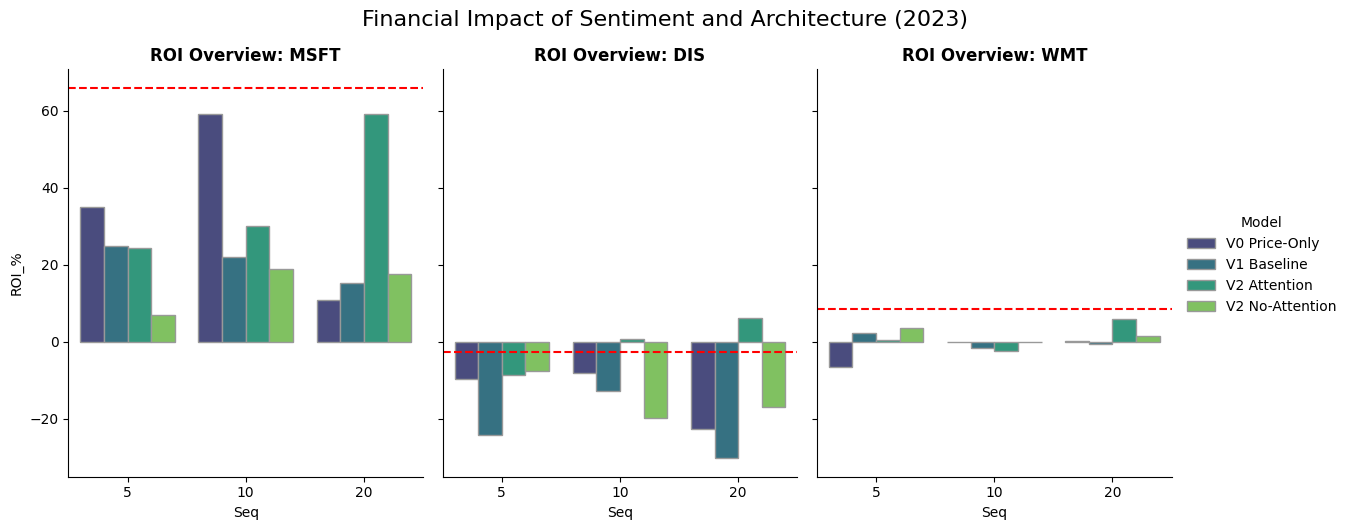

In [6]:
# Cell 6: Comparison Plot
import seaborn as sns
plt.figure(figsize=(15, 6))
g = sns.catplot(
    data=final_df, 
    x="Seq", y="ROI_%", hue="Model", col="Ticker",
    kind="bar", palette="viridis", height=5, aspect=0.8, edgecolor=".6"
)
for ticker, ax in g.axes_dict.items():
    bh_val = final_df[final_df['Ticker'] == ticker]['B&H_%'].iloc[0]
    ax.axhline(bh_val, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f"ROI Overview: {ticker}", fontweight='bold')
    
plt.suptitle("Financial Impact of Sentiment and Architecture (2023)", fontsize=16, y=1.05)
plt.show()
